In [143]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge , LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error, accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [144]:
#Model Creation

#load the cleaned_datawset

path = "../dataset/cleaned_data.csv"
data_df = pd.read_csv(path)

print(f"{data_df.head()}")

#Regresison model : dropping "bmi"
#classification model : dropping "stroke"

x_regression_features = data_df.drop(columns=["bmi"])
y_regression_target = data_df["bmi"]
print(x_regression_features.columns)

x_claasification_features = data_df.drop(columns=["stroke"])
y_classification_target = data_df["stroke"]



      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21  28.1     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
Index(['id', 'gender', 'age', 'hypertension', 'heart_dis

In [123]:
categorical_cols = ["gender","ever_married","work_type","Residence_type","smoking_status"]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

encoder_data = encoder.fit_transform(data_df[categorical_cols])
print("Encoder Shape:", encoder_data.shape)

feature_names = encoder.get_feature_names_out(categorical_cols)

print("Number of feature names:", len(feature_names))
print(feature_names)

#enncoded data into DataFrame
encoded_data_df = pd.DataFrame( encoder_data, columns = feature_names, index=data_df.index)


#update in training dataset
x_reg_train = x_regression_features.copy()
x_reg_train = x_reg_train.drop(columns = categorical_cols)
x_reg_train = pd.concat([x_reg_train,encoded_data_df],axis=1)


x_class_train = x_claasification_features.drop(columns = categorical_cols)
x_class_train = pd.concat([x_class_train,encoded_data_df],axis=1)
print(x_class_train.head())

Encoder Shape: (5130, 11)
Number of feature names: 11
['gender_Male' 'gender_Other' 'ever_married_Yes' 'work_type_Never_worked'
 'work_type_Private' 'work_type_Self-employed' 'work_type_children'
 'Residence_type_Urban' 'smoking_status_formerly smoked'
 'smoking_status_never smoked' 'smoking_status_smokes']
      id   age  hypertension  heart_disease  avg_glucose_level   bmi  \
0   9046  67.0             0              1             228.69  36.6   
1  51676  61.0             0              0             202.21  28.1   
2  31112  80.0             0              1             105.92  32.5   
3  60182  49.0             0              0             171.23  34.4   
4   1665  79.0             1              0             174.12  24.0   

   gender_Male  gender_Other  ever_married_Yes  work_type_Never_worked  \
0          1.0           0.0               1.0                     0.0   
1          0.0           0.0               1.0                     0.0   
2          1.0           0.0        

In [124]:
#Splitting train and test data for regression and cloassification

reg_feature_names = x_reg_train.columns
x_reg_train,  x_reg_test , y_reg_train,y_reg_test = train_test_split(x_reg_train, y_regression_target, test_size=0.2, random_state=42)

scaler_regre= StandardScaler()
x_reg_train = scaler_regre.fit_transform(x_reg_train)
x_reg_test = scaler_regre.transform(x_reg_test)


classif_feature_names = x_class_train.columns
x_class_train,  x_class_test ,y_class_train, y_class_test = train_test_split(x_class_train, y_classification_target, test_size=0.2, random_state=42)
scaler_class = StandardScaler()
x_class_train = scaler_class.fit_transform(x_class_train)
x_class_test = scaler_class.transform(x_class_test)

In [125]:
#Regression Model

model = LinearRegression()

model.fit(x_reg_train,y_reg_train)

y_pred = model.predict(x_reg_test)

mae = mean_absolute_error(y_reg_test, y_pred)

mse = mean_squared_error(y_reg_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_reg_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

coeff_data = pd.DataFrame({
    "Features" : reg_feature_names,
    "co-efficient" : model.coef_,
    "abs_coefficient" : np.abs(model.coef_)
}).sort_values(by = "abs_coefficient",ascending=False)

print(f"Coefficient_data :")
print(coeff_data.head(3))
print()
print(f"Ridge Regression")

#RIDGE REGRESSION
ridge_model = Ridge(alpha =0.1)

ridge_model.fit(x_reg_train,y_reg_train)
ridge_predict = ridge_model.predict(x_reg_test)

ridge_mse = mean_squared_error(y_reg_test, ridge_predict)
ridge_r2 = r2_score(y_reg_test,ridge_predict)

print(f"Ridge MSE : {ridge_mse:.2f}")
print(f"Ridge R2 : {ridge_r2:.2f}")


#Comparing the Linear and Ridge
print()
print(f"Comparison of Linear and Ridge")
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "R²": [r2, ridge_r2]
})

print(comparison_df)

MAE  : 4.98
MSE  : 44.69
RMSE : 6.69
R²   : 0.24
Coefficient_data :
              Features  co-efficient  abs_coefficient
12  work_type_children     -2.804593         2.804593
8     ever_married_Yes      0.943661         0.943661
4    avg_glucose_level      0.801984         0.801984

Ridge Regression
Ridge MSE : 44.69
Ridge R2 : 0.24

Comparison of Linear and Ridge
               Model        MSE        R²
0  Linear Regression  44.692752  0.238101
1   Ridge Regression  44.692790  0.238101


In [126]:
# CLASSIFICATION MODEL
print(data_df["stroke"].unique())
print(y_class_train.value_counts())

#percantage 
sum = y_class_train.value_counts().sum()
print(f"Minority class percentage : {(y_class_train.value_counts().min()/sum)*100:.2f}")

[1 0]
stroke
0    3903
1     201
Name: count, dtype: int64
Minority class percentage : 4.90


In [136]:
#Logistic REgression (using class_weight)

class_model = LogisticRegression(
    class_weight = "balanced",
    random_state =42,
    max_iter = 1000
)

class_model.fit(x_class_train, y_class_train)
pred_set = class_model.predict(x_class_test)
pred_prob = class_model.predict_proba(x_class_test)[:,1]

#confusion matrix
conf_matrix = confusion_matrix(y_class_test,pred_set)
print(f"Confusion Matrix")
print(conf_matrix)

accuracy = accuracy_score(y_class_test,pred_set) *100
print(f"Accuracy : {accuracy:.2f}")

Confusion Matrix
[[746 215]
 [ 24  41]]
Accuracy : 76.71


In [137]:
#Accuracy, Precision, REcall, F1 score
print(f"Classification Report")
print(classification_report(y_class_test, pred_set))

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.78      0.86       961
           1       0.16      0.63      0.26        65

    accuracy                           0.77      1026
   macro avg       0.56      0.70      0.56      1026
weighted avg       0.92      0.77      0.82      1026



AUC : 0.7750260145681581


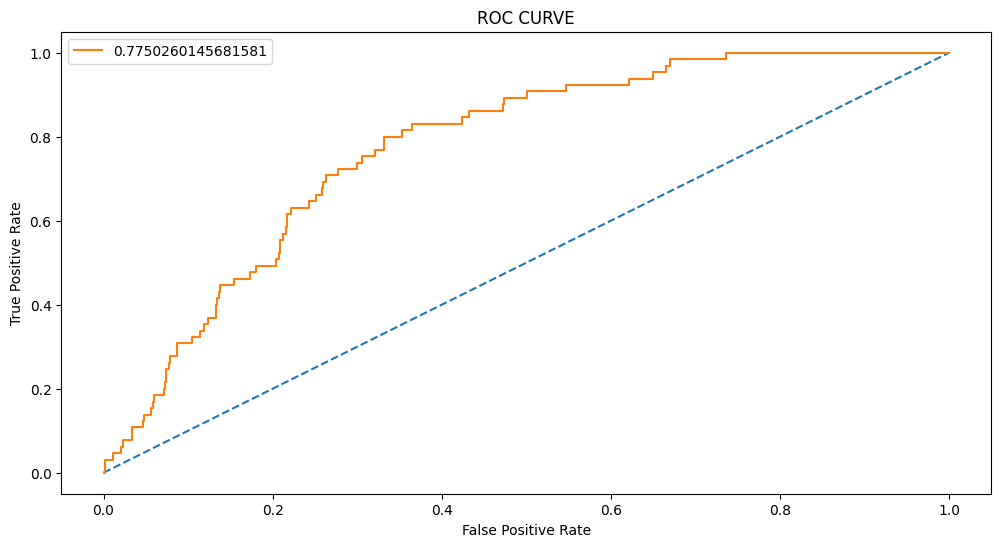

In [157]:
#ROC CURVE

falsePositiveRate, truePositiveRate, thresholds = roc_curve (y_class_test, pred_prob)
auc = roc_auc_score(y_class_test,pred_prob)

print(f"AUC : {auc}")

plt.figure(figsize=(12,6))
plt.plot([0,1], [0,1], linestyle="--")
plt.plot(falsePositiveRate, truePositiveRate, label = auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend()
plt.savefig("../images/ROC_CURVE.png")
plt.show()

In [160]:
# Decision-threshold sensitivity.
from sklearn.metrics import precision_score, recall_score,f1_score

thresholds = [0.30,0.40,0.50,0.60,0.70]

result = []

for threshold in thresholds:
    y_pred = (pred_prob >= threshold).astype(int)

    precision = precision_score(y_class_test,y_pred)
    recall = recall_score(y_class_test,y_pred)
    f1 = f1_score(y_class_test, y_pred)

    result.append([threshold,precision, recall,f1])

result_df = pd.DataFrame(
    result, 
    columns = ["Threshold","Precision","Recall","F1 score"]
)

print(result_df)

   Threshold  Precision    Recall  F1 score
0        0.3   0.125581  0.830769  0.218182
1        0.4   0.142857  0.723077  0.238579
2        0.5   0.160156  0.630769  0.255452
3        0.6   0.152709  0.476923  0.231343
4        0.7   0.164286  0.353846  0.224390


In [162]:
#Regularization on Linear Regression:

model_reg = LogisticRegression(
    C=0.01,
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model_reg.fit(x_class_train, y_class_train)

y_pred_reg = model_reg.predict(x_class_test)
y_prob_reg = model_reg.predict_proba(x_class_test)[:,1]

precision_reg = precision_score(y_class_test, y_pred_reg)
recall_reg = recall_score(y_class_test, y_pred_reg)
auc_reg = roc_auc_score(y_class_test, y_prob_reg)

print("Precision :", precision_reg)
print("Recall    :", recall_reg)
print("AUC       :", auc_reg)


comparison = pd.DataFrame({
    "Model":[
        "Base (C=1.0)",
        "Regularized (C=0.01)"
    ],
    "Precision":[
        precision,precision_reg
    ],
    "Recall":[recall, recall_reg],
    "AUC":[auc, auc_reg]
})

print()
print("Comparison")
print(comparison)

Precision : 0.16071428571428573
Recall    : 0.6923076923076923
AUC       : 0.7879612583046507

Comparison
                  Model  Precision    Recall       AUC
0          Base (C=1.0)   0.164286  0.353846  0.775026
1  Regularized (C=0.01)   0.160714  0.692308  0.787961


In [170]:
#Bootstrap confidence interval for AUC difference

np.random.seed(42)

n_bootstrap =500
auc_diff = []

for i in range(n_bootstrap):
    index = np.random.choice(
        len(y_class_test),
        size = len(y_class_test),
        replace = True
    )

    y_true = y_class_test.iloc[index]
    prob_base = pred_prob[index]
    prob_reg = y_prob_reg[index]

    auc_base = roc_auc_score(y_true, prob_base)
    auc_reg = roc_auc_score(y_true, prob_reg)

    auc_diff.append(auc_base - auc_reg)


mean_diff = np.mean(auc_diff)    
lower = np.percentile(auc_diff, 2.5)
upper = np.percentile(auc_diff, 97.5)
    
print(f"Mean AUC Difference : {mean_diff:.5f}")
print(f"95% Confidence Interval : ({lower:.5f}, {upper:.5f})")    
if lower > 0 or upper < 0:
    print("Confidence interval excludes zero.")
else:
    print("Confidence interval includes zero.")

Mean AUC Difference : -0.01270
95% Confidence Interval : (-0.02512, -0.00039)
Confidence interval excludes zero.
